# Task 3 - Deep Learning with Explainability
## Neural Network for Traffic Demand Prediction

This notebook builds a neural network to predict traffic volume and applies SHAP for model explainability.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

print('OK - Libraries imported')

OK - Libraries imported


In [3]:
# Load data
df = pd.read_csv('Metro_Interstate_Traffic_Volume_part3_preprocessed.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

# Extract features
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['has_holiday'] = df['holiday'].notna().astype(int)

# Cyclical encodings
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['weather_category'] = df['weather_main'].str.lower()

print(f'Data loaded: {df.shape}')

Data loaded: (48187, 22)


In [4]:
# Prepare features
numerical_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week',
                     'month', 'is_weekend', 'has_holiday', 'hour_sin', 'hour_cos',
                     'month_sin', 'month_cos', 'is_low_visibility']

X = df[numerical_features].copy()
weather_dummies = pd.get_dummies(df['weather_category'], prefix='weather')
X = pd.concat([X, weather_dummies], axis=1)

y = df['traffic_volume'].values
feature_names = list(X.columns)

print(f'Features: {len(feature_names)}')

Features: 25


In [5]:
# Split and scale
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}')

Train: (34694, 25), Val: (8674, 25), Test: (4819, 25)


In [6]:
# Build model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mse', metrics=['mae'])
print('Model built')

Model built


In [7]:
# Train
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, 
                                            restore_best_weights=True, verbose=0)

history = model.fit(X_train_scaled, y_train,
                   validation_data=(X_val_scaled, y_val),
                   epochs=100, batch_size=32,
                   callbacks=[early_stop], verbose=0)

print(f'Trained for {len(history.history["loss"])} epochs')

Trained for 20 epochs


In [8]:
# Evaluate
y_test_pred = model.predict(X_test_scaled, verbose=0).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print(f'Test RMSE: {rmse:.0f}, MAE: {mae:.0f}, R2: {r2:.4f}')

Test RMSE: 571, MAE: 378, R2: 0.9181


In [9]:
# SHAP
bg_idx = np.random.choice(X_train_scaled.shape[0], size=100, replace=False)
X_bg = X_train_scaled[bg_idx]

explainer = shap.DeepExplainer(model, X_bg)
shap_vals = np.array(explainer.shap_values(X_test_scaled)).squeeze()

print(f'SHAP values: {shap_vals.shape}')

SHAP values: (4819, 25)


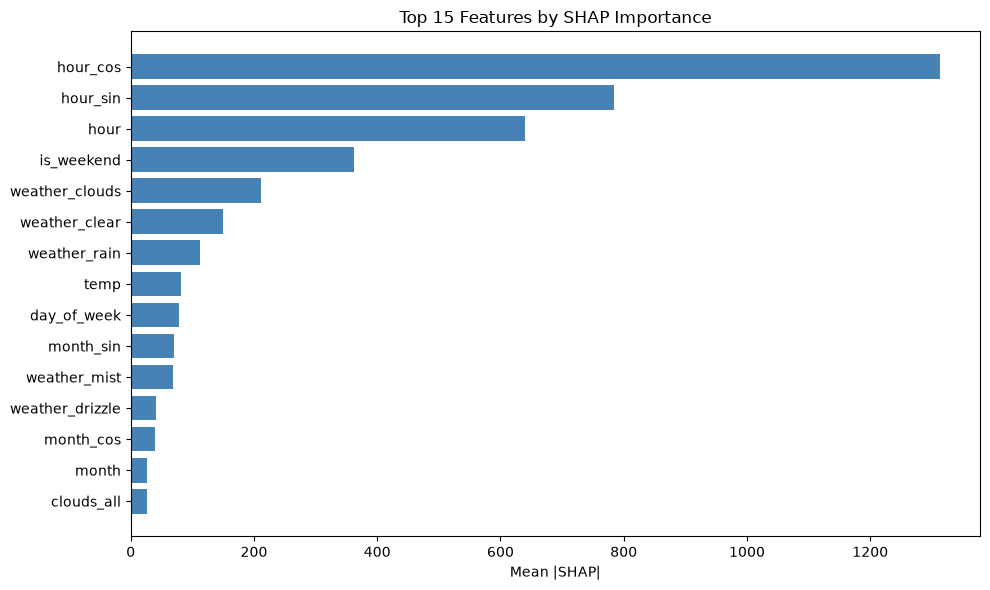

Feature importance plot saved


In [ ]:
# Feature importance
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
importance_df = pd.DataFrame({'feature': feature_names, 'importance': mean_abs_shap})
importance_df = importance_df.sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_15 = importance_df.head(15).sort_values('importance')
ax.barh(top_15['feature'], top_15['importance'], color='steelblue')
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Top 15 Features by SHAP Importance')
plt.tight_layout()
##plt.savefig('06_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('Feature importance plot saved')

In [11]:
print('\\n' + '='*60)
print('TOP 10 FEATURES')
print('='*60)
for idx, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
    print(f'{idx:2d}. {row["feature"]:20s} {row["importance"]:.4f}')

\n============================================================
TOP 10 FEATURES
 1. hour_cos             1312.4871
 2. hour_sin             784.4391
 3. hour                 640.0332
 4. is_weekend           362.6228
 5. weather_clouds       210.6619
 6. weather_clear        149.0185
 7. weather_rain         112.6247
 8. temp                 80.9390
 9. day_of_week          78.8258
10. month_sin            70.2198
